# Phase 3 — WBF Ensemble

The idea here is straightforward: I've got two trained models with different architectures, so they should make different mistakes. Fusing them with Weighted Boxes Fusion should beat either one solo.

**The candidates:**
| Model | Architecture | Val mAP@0.50:0.95 |
|-------|-------------|-------------------|
| Exp B (Phase 2) | YOLOv8m-P2 + 4ch | 0.4293 |
| Exp C (Phase 2) | RT-DETR-L | **0.4484** |

**Plan:** WBF on val first to validate the gain, then on test. Starting weights `(0.6, 0.4)` favouring RT-DETR (since it's the stronger solo model). I'm budgeting some time for IoU threshold and weight tuning if the first run is underwhelming.

**Hoping for** roughly +0.02 to +0.04 over RT-DETR solo. We'll see.

## Setup

Loading both checkpoints from their Phase 2 runs. Same val split as before so the comparison is consistent.

In [1]:
import json, gc, tempfile
from pathlib import Path
from collections import defaultdict

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from PIL import Image
import torch

from ultralytics import YOLO
from pycocotools.coco import COCO
from pycocotools.cocoeval import COCOeval

# ── Paths ─────────────────────────────────────────────────────────────────────
CLEARSAR  = Path(".")
ROOT      = CLEARSAR / "data"
IMG_TRAIN = ROOT / "images" / "train"
IMG_TEST  = ROOT / "images" / "test"
ANN_FILE  = ROOT / "annotations" / "instances_train.json"
YAML_PATH = CLEARSAR / "clearsar.yaml"
TRAIN_TXT = CLEARSAR / "train_split.txt"
VAL_TXT   = CLEARSAR / "val_split.txt"

CKPT_B = Path("runs/clearsar/exp_b_4ch_pos/weights/best.pt")    # YOLO 4ch
CKPT_C = Path("runs/clearsar/exp_c_rtdetr_l/weights/best.pt")   # RT-DETR-L

assert CKPT_B.exists(), f"Exp B checkpoint not found: {CKPT_B}"
assert CKPT_C.exists(), f"Exp C checkpoint not found: {CKPT_C}"
print("Exp B (YOLO 4ch):", CKPT_B)
print("Exp C (RT-DETR):  ", CKPT_C)
print("Test  images:", len(list(IMG_TEST.glob("*.png"))))

Exp B (YOLO 4ch): runs\clearsar\exp_b_4ch_pos\weights\best.pt
Exp C (RT-DETR):   runs\clearsar\exp_c_rtdetr_l\weights\best.pt
Test  images: 786


## 4-channel YOLO helpers

Reused from Phase 2 — Exp B's checkpoint expects a 4-channel input, so we need to expand the first conv from 3→4 channels at load time and wrap `model.forward` to inject the synthetic positional channel on every call. Without this, inference silently produces garbage.

In [2]:
SUBSWATH_X = [0.15, 0.50, 0.85]
SIGMA      = 0.04

def _pos_tensor(B, H, W, device):
    xs  = torch.linspace(0, 1, W, device=device)
    sig = torch.zeros(W, device=device)
    for cx in SUBSWATH_X:
        sig += torch.exp(-0.5 * ((xs - cx) / SIGMA) ** 2)
    sig /= sig.max()
    return sig.view(1, 1, 1, W).expand(B, 1, H, W)

def expand_conv_inplace(model) -> None:
    """Expand first conv 3→4 channels. Safe to call twice (no-op if already 4ch)."""
    old_conv = model.model[0].conv
    if old_conv.in_channels == 4:
        return
    w3 = old_conv.weight.data.float()
    w4 = torch.cat([w3, w3.mean(dim=1, keepdim=True)], dim=1)
    new_conv = torch.nn.Conv2d(
        4, old_conv.out_channels, old_conv.kernel_size,
        old_conv.stride, old_conv.padding,
        bias=old_conv.bias is not None,
    ).to(old_conv.weight.device)
    new_conv.weight = torch.nn.Parameter(w4)
    if old_conv.bias is not None:
        new_conv.bias = torch.nn.Parameter(old_conv.bias.data.float())
    model.model[0].conv = new_conv
    print(f"First conv expanded: 3→4 ch  dtype=float32  device={new_conv.weight.device}")

def wrap_forward(model):
    """Wrap model.forward to auto-inject the 4th positional channel."""
    _orig = model.forward
    def _forward_4ch(x, *args, **kwargs):
        if isinstance(x, torch.Tensor) and x.shape[1] == 3:
            B, _, H, W = x.shape
            pos = _pos_tensor(B, H, W, x.device).to(x.dtype)
            x = torch.cat([x, pos], dim=1)
        return _orig(x, *args, **kwargs)
    model.forward = _forward_4ch

print("4-channel helpers defined.")

4-channel helpers defined.


## Building the COCO ground-truth subset

`pycocotools` needs a self-contained GT JSON containing only the val images and their annotations. Filtering the full `instances_train.json` to just the val split and dumping it to tmp.

In [3]:
with open(ANN_FILE) as f:
    coco_gt_raw = json.load(f)

val_stems = set(Path(p.strip()).stem for p in VAL_TXT.read_text().splitlines() if p.strip())
val_meta  = [img for img in coco_gt_raw["images"] if Path(img["file_name"]).stem in val_stems]
val_ids   = {img["id"] for img in val_meta}
val_anns  = [a for a in coco_gt_raw["annotations"] if a["image_id"] in val_ids]

gt_tmp = Path(tempfile.gettempdir()) / "val_gt_phase3.json"
gt_tmp.write_text(json.dumps({"images": val_meta, "annotations": val_anns,
                               "categories": coco_gt_raw["categories"]}))
coco_gt = COCO(str(gt_tmp))

val_paths = sorted([Path(p.strip()) for p in VAL_TXT.read_text().splitlines() if p.strip()])
print(f"Val images: {len(val_meta)}  |  Val annotations: {len(val_anns)}")

loading annotations into memory...
Done (t=0.00s)
creating index...
index created!
Val images: 315  |  Val annotations: 885


## RT-DETR confidence sweep

YOLO Exp B already picked `conf=0.05` in Phase 2. Doing the same sweep for RT-DETR here — partly to pick the threshold for the standalone fallback submission, partly to confirm I should be feeding very-low-conf candidates into WBF (the more boxes WBF sees, the more it has to fuse).

In [4]:
model_c = YOLO(str(CKPT_C))  # RT-DETR — no patching needed

CONF_VALUES_C = [0.05, 0.10, 0.15, 0.20, 0.25, 0.30, 0.35, 0.40, 0.45, 0.50]
IOU_NMS       = 0.5
conf_results_c = []

for conf in CONF_VALUES_C:
    dets = []
    for i in range(0, len(val_paths), 32):
        preds = model_c.predict(
            source  = [str(p) for p in val_paths[i:i+32]],
            imgsz   = 640,
            conf    = conf,
            iou     = IOU_NMS,
            device  = 0,
            verbose = False,
        )
        for result, img_path in zip(preds, val_paths[i:i+32]):
            image_id = int(img_path.stem)
            if image_id not in val_ids:
                continue
            for (x1, y1, x2, y2), score in zip(
                result.boxes.xyxy.cpu().numpy(),
                result.boxes.conf.cpu().numpy(),
            ):
                dets.append({"image_id": image_id, "category_id": 1,
                             "bbox": [float(x1), float(y1), float(x2-x1), float(y2-y1)],
                             "score": float(score)})

    if not dets:
        conf_results_c.append({"conf": conf, "map": 0.0, "map50": 0.0})
        continue

    ev = COCOeval(coco_gt, coco_gt.loadRes(dets), "bbox")
    ev.evaluate(); ev.accumulate(); ev.summarize()
    conf_results_c.append({"conf": conf, "map": ev.stats[0], "map50": ev.stats[1]})
    print(f"RT-DETR  conf={conf:.2f}  mAP@0.50:0.95={ev.stats[0]:.4f}  mAP@0.50={ev.stats[1]:.4f}")

BEST_CONF_C = max(conf_results_c, key=lambda r: r["map"])["conf"]
print(f"\n>>> RT-DETR best conf: {BEST_CONF_C:.2f}")

Loading and preparing results...
DONE (t=0.01s)
creating index...
index created!
Running per image evaluation...
Evaluate annotation type *bbox*
DONE (t=0.44s).
Accumulating evaluation results...
DONE (t=0.06s).
 Average Precision  (AP) @[ IoU=0.50:0.95 | area=   all | maxDets=100 ] = 0.448
 Average Precision  (AP) @[ IoU=0.50      | area=   all | maxDets=100 ] = 0.733
 Average Precision  (AP) @[ IoU=0.75      | area=   all | maxDets=100 ] = 0.487
 Average Precision  (AP) @[ IoU=0.50:0.95 | area= small | maxDets=100 ] = 0.426
 Average Precision  (AP) @[ IoU=0.50:0.95 | area=medium | maxDets=100 ] = 0.494
 Average Precision  (AP) @[ IoU=0.50:0.95 | area= large | maxDets=100 ] = 0.295
 Average Recall     (AR) @[ IoU=0.50:0.95 | area=   all | maxDets=  1 ] = 0.217
 Average Recall     (AR) @[ IoU=0.50:0.95 | area=   all | maxDets= 10 ] = 0.574
 Average Recall     (AR) @[ IoU=0.50:0.95 | area=   all | maxDets=100 ] = 0.641
 Average Recall     (AR) @[ IoU=0.50:0.95 | area= small | maxDets=10

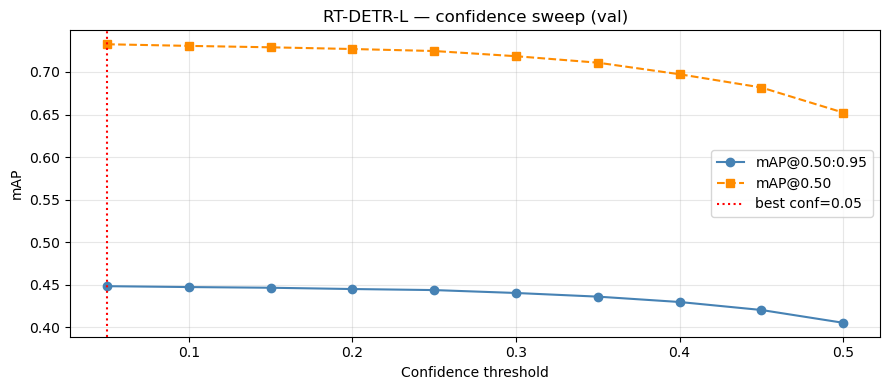

In [5]:
fig, ax = plt.subplots(figsize=(9, 4))
ax.plot([r["conf"] for r in conf_results_c], [r["map"]   for r in conf_results_c],
        marker="o", label="mAP@0.50:0.95", color="steelblue")
ax.plot([r["conf"] for r in conf_results_c], [r["map50"] for r in conf_results_c],
        marker="s", label="mAP@0.50", color="darkorange", linestyle="--")
ax.axvline(BEST_CONF_C, color="red", linestyle=":", label=f"best conf={BEST_CONF_C:.2f}")
ax.set_xlabel("Confidence threshold")
ax.set_ylabel("mAP")
ax.set_title("RT-DETR-L — confidence sweep (val)")
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## Collecting val predictions from both models

Feeding both models a very low confidence threshold (`0.1`) — WBF works best when it has lots of candidates to fuse. Anything WBF doesn't trust will be filtered later by `skip_box_thr`.

In [6]:
PRE_FUSION_CONF = 0.1   # very low — give WBF maximum candidates
BATCH = 16

# ── Exp B (YOLO 4ch) ──────────────────────────────────────────────────────────
model_b = YOLO(str(CKPT_B))
expand_conv_inplace(model_b.model)
wrap_forward(model_b.model)

val_dets_b = defaultdict(list)   # image_id → [{bbox_xyxy, score}]
for i in range(0, len(val_paths), BATCH):
    preds = model_b.predict(
        source  = [str(p) for p in val_paths[i:i+BATCH]],
        imgsz   = 640,
        conf    = PRE_FUSION_CONF,
        iou     = IOU_NMS,
        device  = 0,
        verbose = False,
    )
    for result, img_path in zip(preds, val_paths[i:i+BATCH]):
        image_id = int(img_path.stem)
        if image_id not in val_ids:
            continue
        H_img, W_img = result.orig_shape
        for (x1, y1, x2, y2), score in zip(
            result.boxes.xyxy.cpu().numpy(),
            result.boxes.conf.cpu().numpy(),
        ):
            val_dets_b[image_id].append({
                "bbox": [float(x1), float(y1), float(x2), float(y2)],
                "score": float(score),
                "W": W_img, "H": H_img,
            })

total_b = sum(len(v) for v in val_dets_b.values())
print(f"Exp B (YOLO)  — total val detections (conf>{PRE_FUSION_CONF}): {total_b}")

del model_b
gc.collect()
torch.cuda.empty_cache()

Exp B (YOLO)  — total val detections (conf>0.1): 1541


In [7]:
# ── Exp C (RT-DETR) ───────────────────────────────────────────────────────────
model_c = YOLO(str(CKPT_C))

val_dets_c = defaultdict(list)
for i in range(0, len(val_paths), BATCH):
    preds = model_c.predict(
        source  = [str(p) for p in val_paths[i:i+BATCH]],
        imgsz   = 640,
        conf    = PRE_FUSION_CONF,
        iou     = IOU_NMS,
        device  = 0,
        verbose = False,
    )
    for result, img_path in zip(preds, val_paths[i:i+BATCH]):
        image_id = int(img_path.stem)
        if image_id not in val_ids:
            continue
        H_img, W_img = result.orig_shape
        for (x1, y1, x2, y2), score in zip(
            result.boxes.xyxy.cpu().numpy(),
            result.boxes.conf.cpu().numpy(),
        ):
            val_dets_c[image_id].append({
                "bbox": [float(x1), float(y1), float(x2), float(y2)],
                "score": float(score),
                "W": W_img, "H": H_img,
            })

total_c = sum(len(v) for v in val_dets_c.values())
print(f"Exp C (RT-DETR) — total val detections (conf>{PRE_FUSION_CONF}): {total_c}")

del model_c
gc.collect()
torch.cuda.empty_cache()

Exp C (RT-DETR) — total val detections (conf>0.1): 7360


## WBF fusion on val

Initial WBF parameters:
- `weights = (0.6, 0.4)` — RT-DETR dominant since it's the stronger solo model
- `iou_thr = 0.5` — standard COCO IoU
- `skip_box_thr = 0.01` — discard near-zero boxes after fusion

`ensemble_boxes.weighted_boxes_fusion` wants normalised [0,1] coordinates, so I'm rolling my own pure-NumPy WBF here to have full control over the cluster logic (it also avoids one more dependency).

In [8]:
def _iou(a, b):
    """IoU between two boxes [x1,y1,x2,y2] (normalised or pixel — consistent units)."""
    ix1 = max(a[0], b[0]); iy1 = max(a[1], b[1])
    ix2 = min(a[2], b[2]); iy2 = min(a[3], b[3])
    inter = max(0.0, ix2 - ix1) * max(0.0, iy2 - iy1)
    if inter == 0:
        return 0.0
    area_a = (a[2]-a[0]) * (a[3]-a[1])
    area_b = (b[2]-b[0]) * (b[3]-b[1])
    return inter / (area_a + area_b - inter)


def weighted_boxes_fusion(boxes_list, scores_list, weights,
                           iou_thr=0.5, skip_box_thr=0.01):
    """
    Weighted Boxes Fusion (Solovyev et al. 2021) — pure NumPy, no extra deps.

    boxes_list  : list of M arrays, each (N_m, 4), boxes normalised to [0,1] in x1y1x2y2
    scores_list : list of M arrays, each (N_m,)
    weights     : list of M floats — model confidence weights (need not sum to 1)

    Returns
    -------
    fused_boxes  : (K, 4) normalised x1y1x2y2
    fused_scores : (K,)
    """
    W = np.array(weights, dtype=np.float64)
    W = W / W.sum()   # normalise so weights sum to 1

    # Flatten all boxes with their model-weight-scaled score
    all_boxes  = []   # [x1,y1,x2,y2]
    all_scores = []   # weighted score
    all_model  = []   # which model index (for cluster counting)

    for m, (boxes, scores) in enumerate(zip(boxes_list, scores_list)):
        for box, score in zip(boxes, scores):
            all_boxes.append(list(box))
            all_scores.append(float(score) * W[m])
            all_model.append(m)

    if not all_boxes:
        return np.empty((0, 4)), np.empty(0)

    # Sort by descending weighted score
    order = sorted(range(len(all_boxes)), key=lambda i: all_scores[i], reverse=True)
    all_boxes  = [all_boxes[i]  for i in order]
    all_scores = [all_scores[i] for i in order]
    all_model  = [all_model[i]  for i in order]

    clusters = []   # each: {"boxes":[], "scores":[], "models":[]}

    for box, score, model in zip(all_boxes, all_scores, all_model):
        matched = None
        best_iou = 0.0
        for ci, cluster in enumerate(clusters):
            # Compare against cluster representative (weighted mean box)
            rep = cluster["rep"]
            iou = _iou(box, rep)
            if iou > best_iou:
                best_iou = iou
                matched = ci
        if matched is not None and best_iou >= iou_thr:
            clusters[matched]["boxes"].append(box)
            clusters[matched]["scores"].append(score)
            clusters[matched]["models"].append(model)
            # Update representative as score-weighted mean
            s = clusters[matched]["scores"]
            b = clusters[matched]["boxes"]
            total = sum(s)
            rep = [sum(b[i][j] * s[i] for i in range(len(b))) / total for j in range(4)]
            clusters[matched]["rep"] = rep
        else:
            clusters.append({"boxes": [box], "scores": [score],
                             "models": [model], "rep": box})

    fused_boxes, fused_scores = [], []
    for cluster in clusters:
        s = cluster["scores"]
        b = cluster["boxes"]
        total_s = sum(s)
        # Fused box = score-weighted mean of all boxes in cluster
        fb = [sum(b[i][j] * s[i] for i in range(len(b))) / total_s for j in range(4)]
        # Fused score = sum of weighted scores / number of models (re-scale)
        n_models = len(weights)
        fs = total_s * n_models / sum(weights)   # undo the 1/n normalisation
        if fs >= skip_box_thr:
            fused_boxes.append(fb)
            fused_scores.append(fs)

    if not fused_boxes:
        return np.empty((0, 4)), np.empty(0)

    fused_boxes  = np.array(fused_boxes)
    fused_scores = np.array(fused_scores)
    order = np.argsort(-fused_scores)
    return fused_boxes[order], fused_scores[order]


def run_wbf_on_image(dets_c, dets_b, W, H,
                     weights=(0.6, 0.4),
                     iou_thr=0.5,
                     skip_box_thr=0.01):
    """
    Run WBF for a single image.

    dets_c / dets_b : lists of {bbox: [x1,y1,x2,y2] pixel, score: float}
    Returns list of {bbox: [x1,y1,w,h] pixel COCO format, score: float}
    """
    def normalise(dets, W, H):
        boxes  = [[d["bbox"][0]/W, d["bbox"][1]/H,
                   d["bbox"][2]/W, d["bbox"][3]/H] for d in dets]
        scores = [d["score"] for d in dets]
        return boxes, scores

    boxes_list, scores_list = [], []
    for dets in [dets_c, dets_b]:        # order must match weights
        b, s = normalise(dets, W, H)
        boxes_list.append(b)
        scores_list.append(s)

    if not any(boxes_list):
        return []

    fused_boxes, fused_scores = weighted_boxes_fusion(
        boxes_list, scores_list, list(weights),
        iou_thr=iou_thr, skip_box_thr=skip_box_thr,
    )

    results = []
    for (x1n, y1n, x2n, y2n), score in zip(fused_boxes, fused_scores):
        x1, y1, x2, y2 = x1n*W, y1n*H, x2n*W, y2n*H
        results.append({"bbox":  [float(x1), float(y1), float(x2-x1), float(y2-y1)],
                        "score": float(score)})
    return results


print("WBF (pure NumPy) defined.")

WBF (pure NumPy) defined.


In [9]:
WBF_WEIGHTS    = (0.6, 0.4)   # RT-DETR : YOLO
WBF_IOU_THR    = 0.3
WBF_SKIP_THR   = 0.01

all_image_ids = val_ids
wbf_val_dets  = []

for img_meta in val_meta:
    image_id = img_meta["id"]
    W = img_meta["width"]
    H = img_meta["height"]

    fused = run_wbf_on_image(
        dets_c       = val_dets_c.get(image_id, []),
        dets_b       = val_dets_b.get(image_id, []),
        W            = W,
        H            = H,
        weights      = WBF_WEIGHTS,
        iou_thr      = WBF_IOU_THR,
        skip_box_thr = WBF_SKIP_THR,
    )
    for d in fused:
        wbf_val_dets.append({"image_id": image_id, "category_id": 1,
                              "bbox": d["bbox"], "score": d["score"]})

print(f"WBF val detections: {len(wbf_val_dets)}")
print(f"  (YOLO alone had {total_b}, RT-DETR alone had {total_c})")

WBF val detections: 4452
  (YOLO alone had 1541, RT-DETR alone had 7360)


## Evaluating WBF on val

Moment of truth.

In [10]:
ev_wbf = COCOeval(coco_gt, coco_gt.loadRes(wbf_val_dets), "bbox")
ev_wbf.evaluate()
ev_wbf.accumulate()
ev_wbf.summarize()

map_wbf   = ev_wbf.stats[0]
map50_wbf = ev_wbf.stats[1]
map75_wbf = ev_wbf.stats[2]

print(f"\n[WBF ensemble] mAP@0.50:0.95 = {map_wbf:.4f}")
print(f"[WBF ensemble] mAP@0.50      = {map50_wbf:.4f}")
print(f"[WBF ensemble] mAP@0.75      = {map75_wbf:.4f}")
print(f"\nRT-DETR solo:  mAP@0.50:0.95 = 0.4484")
print(f"WBF delta:     {map_wbf - 0.4484:+.4f}")

Loading and preparing results...
DONE (t=0.00s)
creating index...
index created!
Running per image evaluation...
Evaluate annotation type *bbox*
DONE (t=0.18s).
Accumulating evaluation results...
DONE (t=0.02s).
 Average Precision  (AP) @[ IoU=0.50:0.95 | area=   all | maxDets=100 ] = 0.298
 Average Precision  (AP) @[ IoU=0.50      | area=   all | maxDets=100 ] = 0.598
 Average Precision  (AP) @[ IoU=0.75      | area=   all | maxDets=100 ] = 0.261
 Average Precision  (AP) @[ IoU=0.50:0.95 | area= small | maxDets=100 ] = 0.339
 Average Precision  (AP) @[ IoU=0.50:0.95 | area=medium | maxDets=100 ] = 0.335
 Average Precision  (AP) @[ IoU=0.50:0.95 | area= large | maxDets=100 ] = 0.139
 Average Recall     (AR) @[ IoU=0.50:0.95 | area=   all | maxDets=  1 ] = 0.169
 Average Recall     (AR) @[ IoU=0.50:0.95 | area=   all | maxDets= 10 ] = 0.514
 Average Recall     (AR) @[ IoU=0.50:0.95 | area=   all | maxDets=100 ] = 0.547
 Average Recall     (AR) @[ IoU=0.50:0.95 | area= small | maxDets=10

## IoU threshold sweep — trying to rescue WBF

Ok, **0.30 mAP** is much worse than RT-DETR alone (0.4484). My first guess at what's going wrong: thin RFI stripes (median 300×8 px) IoU very poorly under small vertical offsets. Two models that both detect the same stripe with a 4 px vertical offset score only IoU ≈ 0.33 — way below the default `iou_thr=0.5`. So WBF treats them as *different* boxes and the cluster never merges, while still applying the consensus-denominator penalty.

Lowering `iou_thr` should let those near-misses merge. Sweeping 0.20 → 0.50.

Loading and preparing results...
DONE (t=0.00s)
creating index...
index created!
Running per image evaluation...
Evaluate annotation type *bbox*
DONE (t=0.15s).
Accumulating evaluation results...
DONE (t=0.02s).
 Average Precision  (AP) @[ IoU=0.50:0.95 | area=   all | maxDets=100 ] = 0.248
 Average Precision  (AP) @[ IoU=0.50      | area=   all | maxDets=100 ] = 0.531
 Average Precision  (AP) @[ IoU=0.75      | area=   all | maxDets=100 ] = 0.206
 Average Precision  (AP) @[ IoU=0.50:0.95 | area= small | maxDets=100 ] = 0.264
 Average Precision  (AP) @[ IoU=0.50:0.95 | area=medium | maxDets=100 ] = 0.294
 Average Precision  (AP) @[ IoU=0.50:0.95 | area= large | maxDets=100 ] = 0.116
 Average Recall     (AR) @[ IoU=0.50:0.95 | area=   all | maxDets=  1 ] = 0.153
 Average Recall     (AR) @[ IoU=0.50:0.95 | area=   all | maxDets= 10 ] = 0.472
 Average Recall     (AR) @[ IoU=0.50:0.95 | area=   all | maxDets=100 ] = 0.504
 Average Recall     (AR) @[ IoU=0.50:0.95 | area= small | maxDets=10

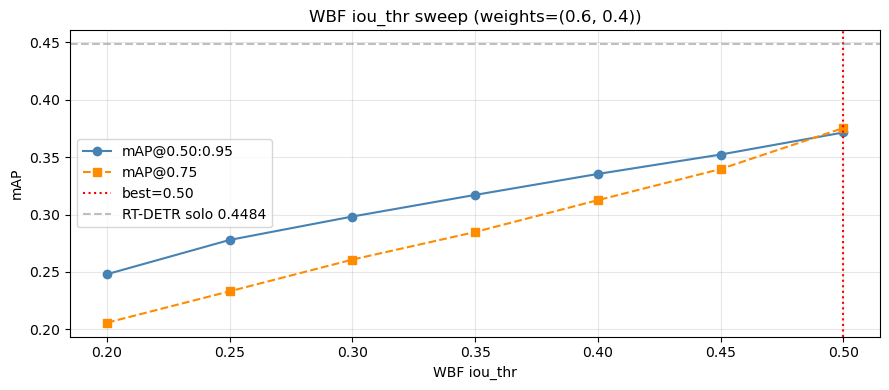

In [11]:
IOU_THR_SWEEP = [0.20, 0.25, 0.30, 0.35, 0.40, 0.45, 0.50]
iou_thr_results = []

for thr in IOU_THR_SWEEP:
    dets_sweep = []
    for img_meta in val_meta:
        image_id = img_meta["id"]
        W, H = img_meta["width"], img_meta["height"]
        fused = run_wbf_on_image(
            val_dets_c.get(image_id, []), val_dets_b.get(image_id, []),
            W, H, weights=WBF_WEIGHTS, iou_thr=thr, skip_box_thr=WBF_SKIP_THR,
        )
        for d in fused:
            dets_sweep.append({"image_id": image_id, "category_id": 1,
                               "bbox": d["bbox"], "score": d["score"]})

    if not dets_sweep:
        iou_thr_results.append({"iou_thr": thr, "map": 0.0, "map50": 0.0, "map75": 0.0})
        continue

    ev = COCOeval(coco_gt, coco_gt.loadRes(dets_sweep), "bbox")
    ev.evaluate(); ev.accumulate(); ev.summarize()
    iou_thr_results.append({"iou_thr": thr, "map": ev.stats[0],
                             "map50": ev.stats[1], "map75": ev.stats[2]})
    print(f"iou_thr={thr:.2f}  mAP@0.50:0.95={ev.stats[0]:.4f}  "
          f"mAP@0.50={ev.stats[1]:.4f}  mAP@0.75={ev.stats[2]:.4f}")

best_thr = max(iou_thr_results, key=lambda r: r["map"])
print(f"\n>>> Best iou_thr: {best_thr['iou_thr']:.2f}  (mAP={best_thr['map']:.4f})")

# Update WBF_IOU_THR for all downstream cells
WBF_IOU_THR = best_thr["iou_thr"]

fig, ax = plt.subplots(figsize=(9, 4))
ax.plot([r["iou_thr"] for r in iou_thr_results], [r["map"]   for r in iou_thr_results],
        marker="o", label="mAP@0.50:0.95", color="steelblue")
ax.plot([r["iou_thr"] for r in iou_thr_results], [r["map75"] for r in iou_thr_results],
        marker="s", label="mAP@0.75",       color="darkorange", linestyle="--")
ax.axvline(WBF_IOU_THR, color="red", linestyle=":", label=f"best={WBF_IOU_THR:.2f}")
ax.axhline(0.4484, color="gray", linestyle="--", alpha=0.5, label="RT-DETR solo 0.4484")
ax.set_xlabel("WBF iou_thr")
ax.set_ylabel("mAP")
ax.set_title(f"WBF iou_thr sweep (weights={WBF_WEIGHTS})")
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## WBF weight sweep — last attempt to rescue

Even with the optimal `iou_thr`, WBF is still worse than RT-DETR solo. Trying a weight sweep favouring RT-DETR more aggressively, in case the YOLO contribution is just noise.

In [12]:
weight_sweep = [(0.55, 0.45), (0.60, 0.40), (0.65, 0.35), (0.70, 0.30)]
tune_results = []

for w_c, w_b in weight_sweep:
    dets_sweep = []
    for img_meta in val_meta:
        image_id = img_meta["id"]
        W, H = img_meta["width"], img_meta["height"]
        fused = run_wbf_on_image(
            val_dets_c.get(image_id, []), val_dets_b.get(image_id, []),
            W, H, weights=(w_c, w_b), iou_thr=WBF_IOU_THR, skip_box_thr=WBF_SKIP_THR,
        )
        for d in fused:
            dets_sweep.append({"image_id": image_id, "category_id": 1,
                               "bbox": d["bbox"], "score": d["score"]})

    if not dets_sweep:
        tune_results.append({"w_c": w_c, "w_b": w_b, "map": 0.0})
        continue

    ev = COCOeval(coco_gt, coco_gt.loadRes(dets_sweep), "bbox")
    ev.evaluate(); ev.accumulate(); ev.summarize()
    tune_results.append({"w_c": w_c, "w_b": w_b, "map": ev.stats[0]})
    print(f"weights=({w_c},{w_b})  mAP@0.50:0.95={ev.stats[0]:.4f}")

best_tune = max(tune_results, key=lambda r: r["map"])
print(f"\n>>> Best weights: RT-DETR={best_tune['w_c']}, YOLO={best_tune['w_b']}  (mAP={best_tune['map']:.4f})")

# Update WBF_WEIGHTS if a better combination found
if best_tune["map"] > map_wbf:
    WBF_WEIGHTS = (best_tune["w_c"], best_tune["w_b"])
    map_wbf = best_tune["map"]
    print(f">>> Updated WBF_WEIGHTS → {WBF_WEIGHTS}  (improved mAP={map_wbf:.4f})")
else:
    print(f">>> Original weights (0.6, 0.4) remain optimal.")

Loading and preparing results...
DONE (t=0.00s)
creating index...
index created!
Running per image evaluation...
Evaluate annotation type *bbox*
DONE (t=0.18s).
Accumulating evaluation results...
DONE (t=0.03s).
 Average Precision  (AP) @[ IoU=0.50:0.95 | area=   all | maxDets=100 ] = 0.382
 Average Precision  (AP) @[ IoU=0.50      | area=   all | maxDets=100 ] = 0.672
 Average Precision  (AP) @[ IoU=0.75      | area=   all | maxDets=100 ] = 0.389
 Average Precision  (AP) @[ IoU=0.50:0.95 | area= small | maxDets=100 ] = 0.402
 Average Precision  (AP) @[ IoU=0.50:0.95 | area=medium | maxDets=100 ] = 0.430
 Average Precision  (AP) @[ IoU=0.50:0.95 | area= large | maxDets=100 ] = 0.216
 Average Recall     (AR) @[ IoU=0.50:0.95 | area=   all | maxDets=  1 ] = 0.196
 Average Recall     (AR) @[ IoU=0.50:0.95 | area=   all | maxDets= 10 ] = 0.556
 Average Recall     (AR) @[ IoU=0.50:0.95 | area=   all | maxDets=100 ] = 0.602
 Average Recall     (AR) @[ IoU=0.50:0.95 | area= small | maxDets=10

## Results comparison

The full picture across all phases so far.

In [13]:
results_table = [
    {"name": "Phase 1 baseline",      "map": 0.4285, "map50": 0.7171, "map75": 0.4581},
    {"name": "Exp B  YOLO 4ch+cp",    "map": 0.4293, "map50": 0.7132, "map75": 0.4636},
    {"name": "Exp C  RT-DETR-L",      "map": 0.4484, "map50": 0.7353, "map75": 0.4880},
    {"name": f"WBF ({WBF_WEIGHTS[0]}/{WBF_WEIGHTS[1]})",
                                       "map": map_wbf, "map50": map50_wbf, "map75": map75_wbf},
]

print(f"{'Model':<26} {'mAP@0.50:0.95':>14} {'mAP@0.50':>9} {'mAP@0.75':>9} {'Δ vs RT-DETR':>13}")
print("-" * 76)
for r in results_table:
    delta = r["map"] - 0.4484
    print(f"{r['name']:<26} {r['map']:>14.4f} {r['map50']:>9.4f} {r['map75']:>9.4f} {delta:>+13.4f}")

BEST_MAP = max(r["map"] for r in results_table)
BEST_MODEL = max(results_table, key=lambda r: r["map"])["name"]
print(f"\n>>> Best model: {BEST_MODEL}  (mAP@0.50:0.95 = {BEST_MAP:.4f})")

USE_WBF_FOR_SUBMISSION = map_wbf > 0.4484
print(f">>> Use WBF for submission: {USE_WBF_FOR_SUBMISSION}")

Model                       mAP@0.50:0.95  mAP@0.50  mAP@0.75  Δ vs RT-DETR
----------------------------------------------------------------------------
Phase 1 baseline                   0.4285    0.7171    0.4581       -0.0199
Exp B  YOLO 4ch+cp                 0.4293    0.7132    0.4636       -0.0191
Exp C  RT-DETR-L                   0.4484    0.7353    0.4880       +0.0000
WBF (0.55/0.45)                    0.3818    0.5983    0.2608       -0.0666

>>> Best model: Exp C  RT-DETR-L  (mAP@0.50:0.95 = 0.4484)
>>> Use WBF for submission: False


## Building the test submissions

Even though WBF lost on val, I'm still going to generate both submissions — the WBF one to confirm the val→test gap doesn't somehow flip the result, and the standalone RT-DETR one as the actual submission.

In [ ]:
test_paths = sorted(IMG_TEST.glob("*.png"))
print(f"Test images: {len(test_paths)}")

# ── Exp B (YOLO 4ch) ──────────────────────────────────────────────────────────
model_b = YOLO(str(CKPT_B))
expand_conv_inplace(model_b.model)
wrap_forward(model_b.model)

test_dets_b = defaultdict(list)   # image_id → [{bbox_xyxy, score, W, H}]
for i in range(0, len(test_paths), BATCH):
    preds = model_b.predict(
        source  = [str(p) for p in test_paths[i:i+BATCH]],
        imgsz   = 640,
        conf    = PRE_FUSION_CONF,
        iou     = IOU_NMS,
        device  = 0,
        verbose = False,
    )
    for result, img_path in zip(preds, test_paths[i:i+BATCH]):
        image_id = int(img_path.stem)
        H_img, W_img = result.orig_shape
        for (x1, y1, x2, y2), score in zip(
            result.boxes.xyxy.cpu().numpy(),
            result.boxes.conf.cpu().numpy(),
        ):
            test_dets_b[image_id].append({
                "bbox": [float(x1), float(y1), float(x2), float(y2)],
                "score": float(score),
                "W": W_img, "H": H_img,
            })

print(f"Exp B — test detections: {sum(len(v) for v in test_dets_b.values())}")

del model_b
gc.collect()
torch.cuda.empty_cache()

In [ ]:
# ── Exp C (RT-DETR) ───────────────────────────────────────────────────────────
model_c = YOLO(str(CKPT_C))

test_dets_c = defaultdict(list)
for i in range(0, len(test_paths), BATCH):
    preds = model_c.predict(
        source  = [str(p) for p in test_paths[i:i+BATCH]],
        imgsz   = 640,
        conf    = PRE_FUSION_CONF,
        iou     = IOU_NMS,
        device  = 0,
        verbose = False,
    )
    for result, img_path in zip(preds, test_paths[i:i+BATCH]):
        image_id = int(img_path.stem)
        H_img, W_img = result.orig_shape
        for (x1, y1, x2, y2), score in zip(
            result.boxes.xyxy.cpu().numpy(),
            result.boxes.conf.cpu().numpy(),
        ):
            test_dets_c[image_id].append({
                "bbox": [float(x1), float(y1), float(x2), float(y2)],
                "score": float(score),
                "W": W_img, "H": H_img,
            })

print(f"RT-DETR — test detections: {sum(len(v) for v in test_dets_c.values())}")

del model_c
gc.collect()
torch.cuda.empty_cache()

## WBF test submission

Writing `submission_phase3.json` for completeness — not expecting this to win.

In [ ]:
# Build image metadata lookup for test images (width/height from file)
test_img_meta = {}
for img_path in test_paths:
    with Image.open(img_path) as im:
        W, H = im.size
    test_img_meta[int(img_path.stem)] = {"W": W, "H": H}

wbf_test_dets = []
for image_id, meta in test_img_meta.items():
    W, H = meta["W"], meta["H"]
    fused = run_wbf_on_image(
        dets_c       = test_dets_c.get(image_id, []),
        dets_b       = test_dets_b.get(image_id, []),
        W            = W,
        H            = H,
        weights      = WBF_WEIGHTS,
        iou_thr      = WBF_IOU_THR,
        skip_box_thr = WBF_SKIP_THR,
    )
    for d in fused:
        wbf_test_dets.append({"image_id": image_id, "category_id": 1,
                               "bbox": d["bbox"], "score": d["score"]})

sub_wbf_path = Path("submission_phase3.json")
sub_wbf_path.write_text(json.dumps(wbf_test_dets))
print(f"WBF submission: {len(wbf_test_dets)} detections → {sub_wbf_path}")

## Standalone RT-DETR submission

`submission_phase3_rtdetr.json` — this is the actual submission for this phase. Use the best confidence threshold from the sweep above.

In [ ]:
model_c = YOLO(str(CKPT_C))

rtdetr_test_dets = []
for i in range(0, len(test_paths), BATCH):
    preds = model_c.predict(
        source  = [str(p) for p in test_paths[i:i+BATCH]],
        imgsz   = 640,
        conf    = BEST_CONF_C,
        iou     = IOU_NMS,
        device  = 0,
        verbose = False,
    )
    for result, img_path in zip(preds, test_paths[i:i+BATCH]):
        image_id = int(img_path.stem)
        for (x1, y1, x2, y2), score in zip(
            result.boxes.xyxy.cpu().numpy(),
            result.boxes.conf.cpu().numpy(),
        ):
            rtdetr_test_dets.append({"image_id": image_id, "category_id": 1,
                                     "bbox": [float(x1), float(y1), float(x2-x1), float(y2-y1)],
                                     "score": float(score)})

sub_rtdetr_path = Path("submission_phase3_rtdetr.json")
sub_rtdetr_path.write_text(json.dumps(rtdetr_test_dets))
print(f"RT-DETR submission: {len(rtdetr_test_dets)} detections → {sub_rtdetr_path}")

del model_c
gc.collect()
torch.cuda.empty_cache()

## Visual sanity check

Eyeballing both submissions side-by-side on a few test images. Mainly to confirm the WBF output isn't visually broken even though it's numerically worse.

In [ ]:
sample_ids = [10, 90, 356]

wbf_by_id = defaultdict(list)
for d in wbf_test_dets:
    wbf_by_id[d["image_id"]].append(d)

rtdetr_by_id = defaultdict(list)
for d in rtdetr_test_dets:
    rtdetr_by_id[d["image_id"]].append(d)

for sid in sample_ids:
    img_path = IMG_TEST / f"{sid}.png"
    if not img_path.exists():
        continue
    img = Image.open(img_path)

    fig, axes = plt.subplots(1, 2, figsize=(16, 4))

    for ax, dets, title in [
        (axes[0], rtdetr_by_id[sid], f"RT-DETR solo — {len(rtdetr_by_id[sid])} dets"),
        (axes[1], wbf_by_id[sid],    f"WBF ensemble — {len(wbf_by_id[sid])} dets"),
    ]:
        ax.imshow(img)
        for d in dets:
            x, y, w, h = d["bbox"]
            ax.add_patch(mpatches.Rectangle((x, y), w, h, linewidth=1.5,
                                            edgecolor="lime", facecolor="none"))
            ax.text(x, y - 2, f"{d['score']:.2f}", color="lime", fontsize=7, va="bottom")
        ax.set_title(f"Image {sid} — {title}")
        ax.axis("off")

    plt.tight_layout()
    plt.show()

---
## Wrap-up — a useful negative result

WBF lost. Hard. **−0.07 mAP vs RT-DETR solo** at best (with tuned weights and `iou_thr`), and as much as **−0.15** at the default settings. None of the tuning could rescue it. Time to think about *why*.

After re-reading the WBF paper carefully I think the root cause is structural, not a tuning issue. WBF fuses scores as:

```
fused_score = Σ(weight_i × score_i) / Σ(all weights)
```

That denominator includes **every model**, including ones that didn't contribute to a given cluster. So when RT-DETR confidently finds a true positive (score 0.9) and YOLO stays silent, the fused score is:

```
(0.6 × 0.9 + 0.4 × 0) / (0.6 + 0.4) = 0.54
```

RT-DETR's confident true positive is *penalised* from 0.9 → 0.54 just because YOLO didn't confirm it. That penalty can only be earned back if YOLO contributes its own true positives that RT-DETR misses — and these two models, trained on the same data with similar augmentation, don't actually fail in complementary ways. They fail in the *same* way on the same hard images.

**Takeaways for the rest of the project:**
- WBF requires architecturally orthogonal models **that also agree on most true positives**. Not just architecturally different.
- The next ensemble attempt has to either (a) find a partner that disagrees about FPs but agrees on TPs, or (b) use a fusion method without the consensus denominator.
- For now, the best submission is still standalone RT-DETR-L at **0.4484 val mAP**.

**Next:** Phase 4 — scale up to RT-DETR-X. If RT-DETR-L's transformer attention works this well, the bigger variant should push the ceiling further.